In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Được mệnh danh là "Vị vua của Đại Tây Dương", Titanic không chỉ là biểu tượng của sự xa xỉ và công nghệ tiên tiến thời đó, mà còn gắn liền với một bi kịch chưa từng có trong lịch sử hàng hải.

Titanic được đặt ra hạ thủy vào năm 1911 và khởi hành trên hành trình đầu tiên từ Southampton, Anh đến New York, Mỹ vào ngày 10 tháng 4 năm 1912. Với bề dày 269 mét, trọng lượng 52,310 tấn và chứa đựng hơn 2,200 hành khách cùng thủy thủ đoàn, Titanic khi đó là con tàu lớn nhất và xa xỉ nhất thế giới. Tuy nhiên, một bi kịch không lường trước đã xảy ra khi con tàu này va chạm với một tảng băng trôi lớn vào ngày 14 tháng 4 năm 1912 và chìm xuống Đại Tây Dương sau đó chỉ 2 giờ 40 phút.

# Import thư viện

In [2]:
# Nhập thư viện Matplotlib và Seaborn để trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Nhập bộ dataset

In [3]:
# Nhập bộ dataset Titanic trong folder data có tên là 'titanic.csv'
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Machine_learning/learn_EDA/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Vẽ đồ thị với x là sống/chết, y là các cột khác

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Categories

In [5]:
cat_cols = ['Sex','Pclass','Embarked']

In [6]:
df['SurvivedLabel'] = df['Survived'].map({0:'Dead', 1:'Alive'})
cols = [c for c in df.columns if c not in ['Survived','SurvivedLabel']]
cat_auto = [c for c in cols if df[c].nunique() <= 10 and df[c].dtype == 'object']
num_auto = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

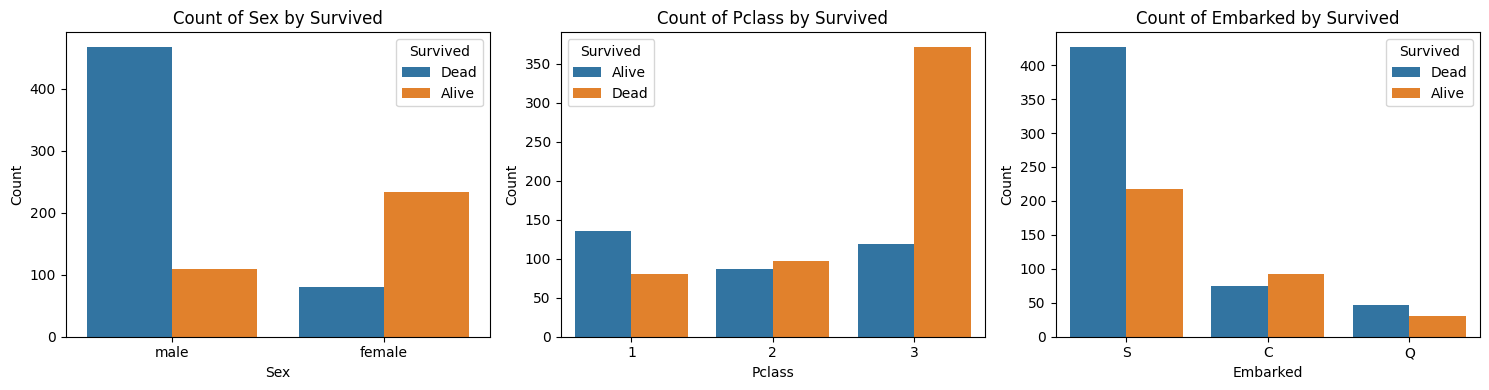

In [7]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 4))
for i,col in enumerate (cat_cols):
  sns.countplot(data=df, x=col, hue='SurvivedLabel', ax=axes[i])
  axes[i].set_title(f'Count of {col} by Survived')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
  axes[i].legend(title='Survived')
plt.tight_layout()
plt.show()


 **Giới tính**
   Sex: Nam có tỉ lệ tử vong cao hơn hẳn so với tỉ lệ sống sót
        Nữ có tỉ lệ sống sót cao hơn hẳn so với tử vong
  Có thể thấy phụ nữ được ưu tiên cứu hộ hơn nam giới trong thảm họa Titanic. Điều này phản ánh quy tắc "phụ nữ và trẻ em được cứu trước".


 **Hạng vé (Pclass) và Tỷ lệ sống sót**
- Hạng 1 có số người sống sót cao hơn số người tử vong.
- Hạng 2 có tỷ lệ sống và chết gần như ngang nhau.
- Hạng 3 có số người tử vong vượt trội so với số người sống sót.
 Nhận xét: Hành khách hạng cao có cơ hội sống sót cao hơn, có thể do vị trí cabin gần khu vực cứu hộ hoặc được ưu tiên hơn.
  **Cảng  lên tàu (Embarked) và Tỷ lệ sống sót**
- Cảng S (Southampton) có số lượng hành khách đông nhất, nhưng tỷ lệ tử vong cao hơn sống sót.
- Cảng C (Cherbourg) có tỷ lệ sống sót cao hơn tử vong.
- Cảng Q (Queenstown) có ít hành khách, nhưng sống sót nhỉnh hơn tử vong. 👉 Nhận xét: Cảng lên tàu có thể phản ánh sự khác biệt về điều kiện kinh tế hoặc vị trí cabin, ảnh hưởng đến khả năng sống sót.

Kết luận: Những cột này có khả năng ảnh hưởng cao trong mô hình dự đoán



## Numberies

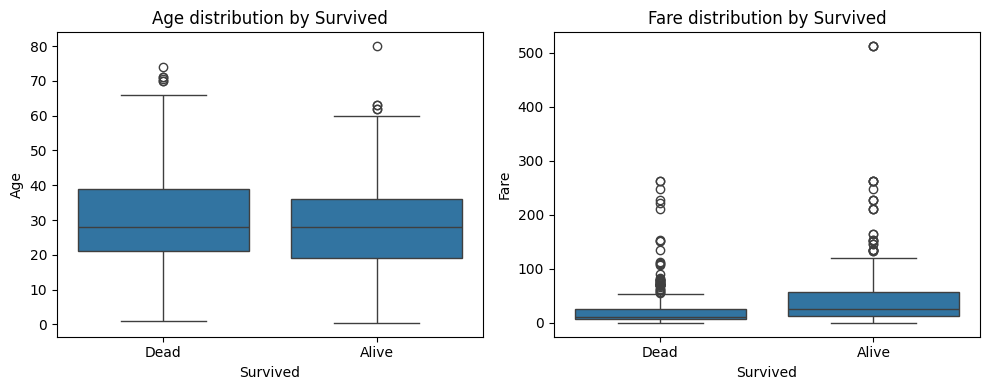

In [8]:
num_cols = ['Age','Fare']   # hoặc ['Age','Fare']

fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='SurvivedLabel', y=col, ax=axes[i])
    axes[i].set_title(f'{col} distribution by Survived')
    axes[i].set_xlabel('Survived')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

📊 **1. Phân phối tuổi (Age) theo sống sót**
- Median tuổi của cả hai nhóm (Dead và Alive) gần như bằng nhau, khoảng 28–30 tuổi.
- Khoảng biến thiên (IQR) của nhóm tử vong rộng hơn một chút, cho thấy độ phân tán tuổi lớn hơn.
- Outliers xuất hiện ở cả hai nhóm, đặc biệt là những người trên 70 tuổi.
**👉 Nhận xét:**
Tuổi không phải là yếu tố quyết định rõ ràng đến khả năng sống sót. Tuy nhiên, có thể phân tích sâu hơn theo nhóm tuổi (trẻ em, người già) để thấy xu hướng rõ hơn.

**💰 2. Phân phối giá vé (Fare) theo sống sót**
- Median giá vé của nhóm sống sót cao hơn rõ rệt so với nhóm tử vong.
- IQR của nhóm sống sót rộng hơn, cho thấy sự đa dạng về mức giá vé trong nhóm này.
- Có nhiều outliers với giá vé rất cao (trên 500), chủ yếu thuộc nhóm sống sót.
👉 Nhận xét:
Giá vé có thể phản ánh hạng vé hoặc điều kiện kinh tế. Người trả giá vé cao (có thể thuộc hạng 1) có khả năng sống sót cao hơn.
** Đây là một biến quan trọng trong phân tích.**




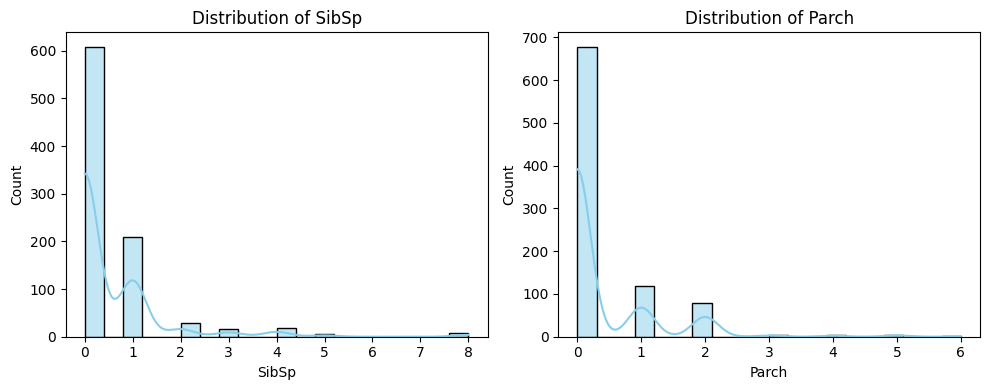

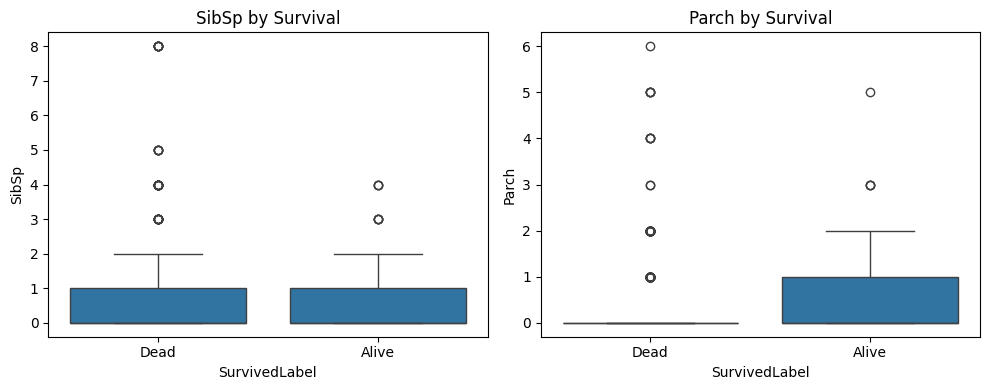

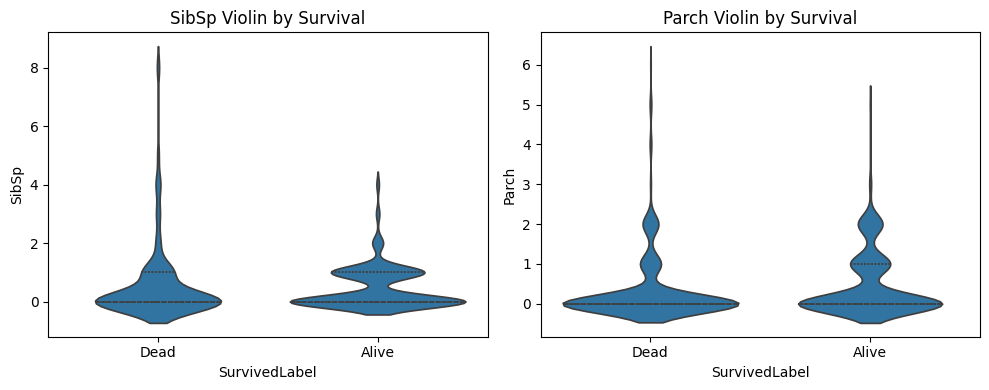

In [9]:


num_cols = [ 'SibSp', 'Parch']

# ---- 2️⃣ Vẽ histogram (phân bố dữ liệu) ----
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# ---- 3️⃣ Vẽ boxplot so sánh với Survived ----
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='SurvivedLabel', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Survival')
plt.tight_layout()
plt.show()

# ---- 4️⃣ Vẽ violinplot (phân bố mịn hơn boxplot) ----
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='SurvivedLabel', y=col, inner='quartile', ax=axes[i])
    axes[i].set_title(f'{col} Violin by Survival')
plt.tight_layout()
plt.show()


**👨‍👩‍👧‍👦 1. Phân phối SibSp và Parch (histogram)**
- SibSp: Phần lớn hành khách đi **một mình (SibSp = 0)**. Số lượng người đi cùng từ 1–3 giảm dần, rất **ít người có từ 4 trở lên**.
- Parch: Tương tự, đa số hành khách không đi cùng cha mẹ hoặc con cái (Parch = 0). Số lượng người có **Parch > 1 rất thấp**.
👉 Nhận xét:
Hành khách trên tàu Titanic chủ yếu đi một mình hoặc với một người thân. Việc có nhiều người thân đi cùng là hiếm, và có thể ảnh hưởng đến khả năng phản ứng khi thảm họa xảy ra.

**- SibSp:**
- Cả hai nhóm (Dead và Alive) đều có median = 0, tức là phần lớn hành khách không đi cùng anh chị em/vợ chồng.
- Có một số outliers với SibSp lên đến 8, chủ yếu ở nhóm tử vong.
- Nhóm sống sót có IQR hẹp hơn, cho thấy ít người sống sót có nhiều người thân đi cùng.

**Parch**
- Nhóm có Parch > 0 (đi cùng cha mẹ/con cái) có tỷ lệ sống sót cao hơn một chút.
- Có thể do được ưu tiên cứu hộ hoặc hỗ trợ lẫn nhau.


## PClass
PClass (Giá vé): Khá là quan trọng bởi vì nó phản ảnh địa vị xã hội, điều kiện cabin, và khả năng tiếp cận cứu hộ.


/tmp/ipython-input-3082858138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='Set2')


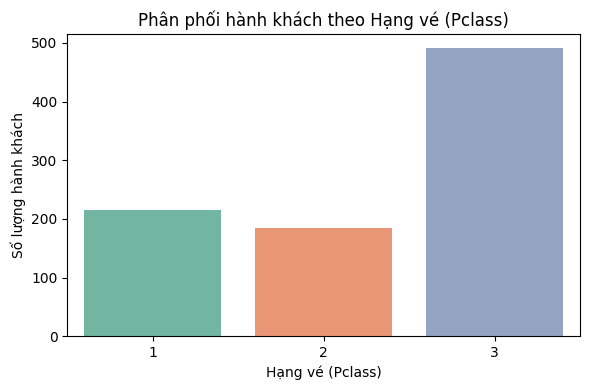

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', palette='Set2')
plt.title('Phân phối hành khách theo Hạng vé (Pclass)')
plt.xlabel('Hạng vé (Pclass)')
plt.ylabel('Số lượng hành khách')
plt.tight_layout()
plt.show()

/tmp/ipython-input-776663451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate, x='Pclass', y='Survived', palette='Set2')


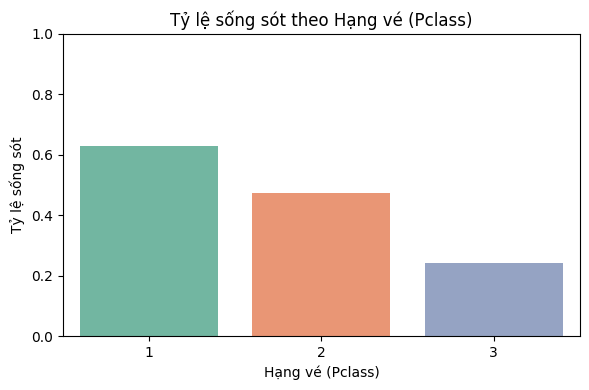

In [15]:
survival_rate = df.groupby('Pclass')['Survived'].mean().reset_index()

# Vẽ biểu đồ tỷ lệ sống sót
plt.figure(figsize=(6,4))
sns.barplot(data=survival_rate, x='Pclass', y='Survived', palette='Set2')
plt.title('Tỷ lệ sống sót theo Hạng vé (Pclass)')
plt.xlabel('Hạng vé (Pclass)')
plt.ylabel('Tỷ lệ sống sót')
plt.ylim(0, 1)  # Giới hạn từ 0 đến 1 cho dễ nhìn
plt.tight_layout()
plt.show()

/tmp/ipython-input-2078606040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


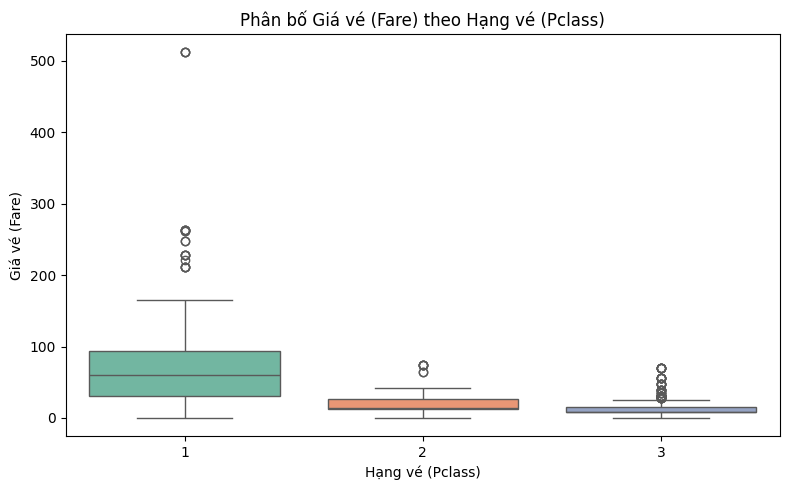

In [16]:
plt.figure(figsize=(8,5))

# Vẽ boxplot Fare theo Pclass
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')

plt.title('Phân bố Giá vé (Fare) theo Hạng vé (Pclass)')
plt.xlabel('Hạng vé (Pclass)')
plt.ylabel('Giá vé (Fare)')
plt.tight_layout()
plt.show()

###Parch có ảnh hưởng đến tỷ lệ sống sót như thế nào khi kết hợp với giới tính?

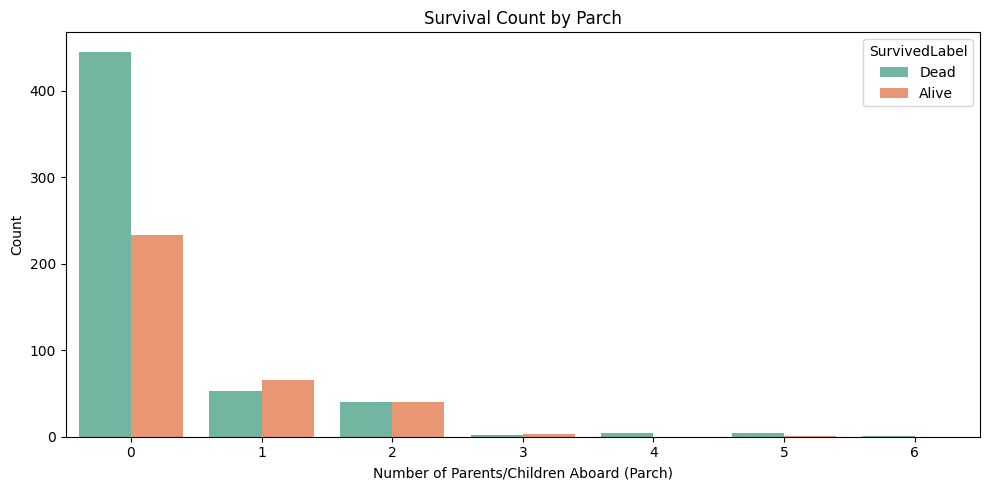

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Parch', hue='SurvivedLabel', palette='Set2', dodge=True)
plt.title('Survival Count by Parch')
plt.xlabel('Number of Parents/Children Aboard (Parch)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


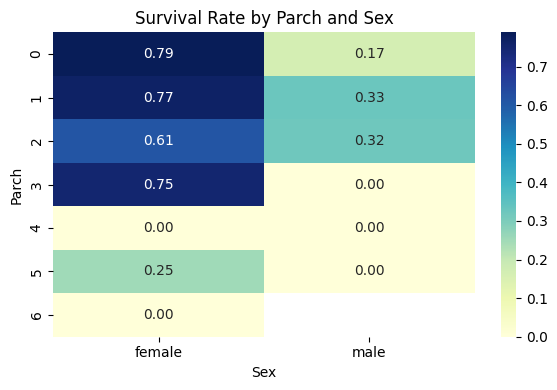

In [11]:
pivot = df.pivot_table(values='Survived', index='Parch', columns='Sex', aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Survival Rate by Parch and Sex')
plt.ylabel('Parch')
plt.xlabel('Sex')
plt.tight_layout()
plt.show()


- Giới tính là yếu tố chính: nữ sống sót nhiều hơn nam ở mọi mức Parch.
- Parch ảnh hưởng rõ nhất khi ở mức nhỏ (1–3): phụ nữ đi cùng gia đình nhỏ có tỷ lệ sống cao.
- Parch lớn (≥4) làm giảm tỷ lệ sống ở cả nam và nữ, đặc biệt rõ ở nữ khi tỷ lệ rơi về 0.
👉 Vậy nên: Parch ảnh hưởng đến nữ, nhưng chỉ khi kết hợp với nhóm nhỏ. Nếu đi quá đông, thì ảnh hưởng trở nên tiêu cực.


### Có phải tất cả phụ nữ đều có tỷ lệ sống cao, hay chỉ ở một số nhóm tuổi hoặc hạng vé?


/tmp/ipython-input-1537324123.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2', ci=None)


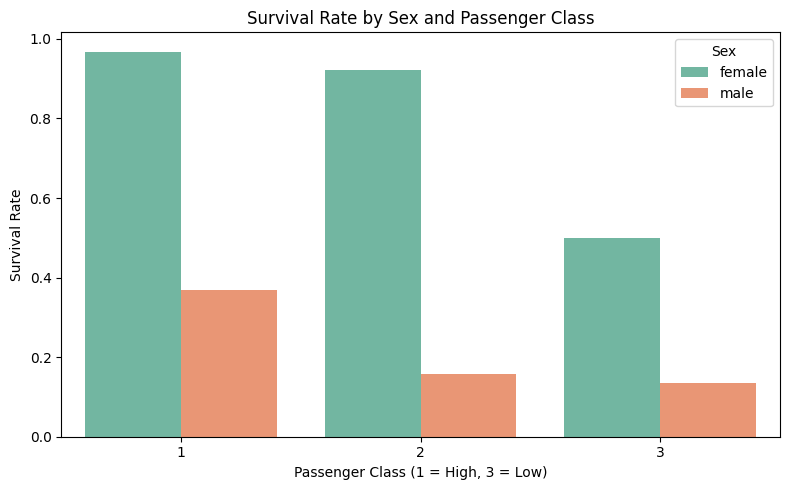

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2', ci=None)
plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class (1 = High, 3 = Low)')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()


   - Phụ nữ ở hạng vé 1,2 có tỉ lệ sống rất cao, gần như bằng 1. Có thể do ở gần cabin nên được ưu tiên cứu hộ
   - Ở hạng vé 3 thì tỉ lệ sống giảm rõ rệt
   - Tỷ lệ sống sót ~40% → cao hơn các hạng khác, nhưng vẫn thấp hơn nhiều so với nữ cùng hạng.
  - Có thể do vị trí cabin thuận lợi hơn, hoặc có cơ hội tiếp cận cứu hộ sớm hơn.
Tuy nhiên, ở hạng vé 3 tỉ lệ sống sót của nam giảm rõ rệt, phản ánh rõ sự bất bình đẳng
   

/tmp/ipython-input-912875235.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='AgeGroup', y='Survived', hue='Sex', palette='Set2', ci=None)


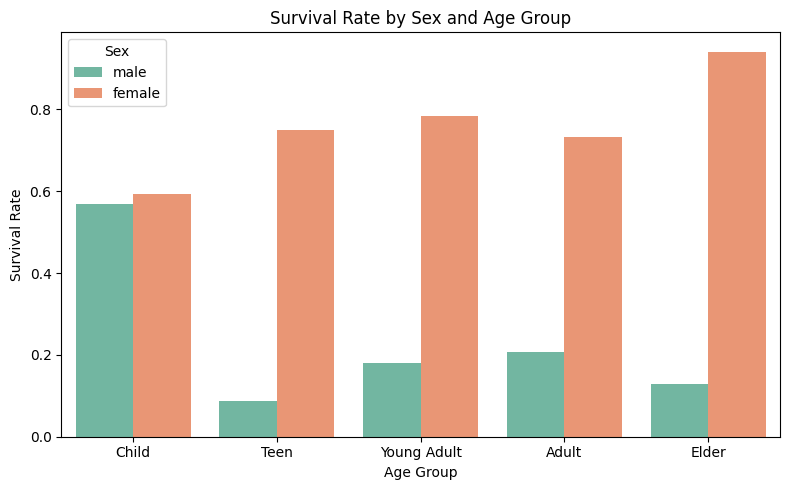

In [13]:
bins = [0, 12, 18, 35, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Elder']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='AgeGroup', y='Survived', hue='Sex', palette='Set2', ci=None)
plt.title('Survival Rate by Sex and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()


- Giới tính là yếu tố quyết định mạnh nhất: nữ sống cao hơn nam ở mọi độ tuổi.
- Tuổi ảnh hưởng rõ đến nam giới: chỉ trẻ em nam có tỷ lệ sống cao, còn lại rất thấp.
- Phụ nữ lớn tuổi vẫn được ưu tiên cứu hộ, phản ánh rõ nét văn hóa thời điểm đó.
